# Sprint 4 – Avaliação Final, Interpretação e Apresentação
### Grupo 4 · Engenharia de Software · Introdução à IA e Análise de Dados
**Prof. Wesley Andrade**

---

**Contexto:** Ao longo de 3 sprints, construímos um projeto completo de ML: EDA com hipóteses (Sprint 1), Pipeline de pré-processamento com feature engineering (Sprint 2), e modelagem com HistGradientBoosting ajustado (Sprint 3, R² ≈ 0.45, RMSE ≈ 16.6).

**Objetivo desta sprint:** ir além dos números — entender *onde* e *por que* o modelo erra, interpretar o que ele aprendeu, revisitar as hipóteses iniciais e documentar limitações com honestidade.

---
### Estrutura (5 seções conforme enunciado)
| # | Seção | Peso |
|---|---|---|
| 1 | Análise de Erros | 20% |
| 2 | Interpretação do Modelo | 20% |
| 3 | Revisão das Hipóteses | 15% |
| 4 | Resumo de Desempenho Consolidado | — |
| 5 | Limitações e Melhorias Futuras | — |


In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_raw = pd.read_csv('spotify-tracks-dataset.csv')
df = df_raw.dropna().copy()
cols_remover = [c for c in df.columns if c.startswith('Unnamed')]
cols_remover += ['track_id', 'artists', 'album_name', 'track_name']
cols_remover = [c for c in cols_remover if c in df.columns]
df = df.drop(columns=cols_remover)

# Filtro de podcasts ANTES do split (como a Sprint 2 fez)
mask_podcast = (
    (df['speechiness'] > 0.66) &
    (df['duration_ms'] > 600_000) &
    (df['instrumentalness'] < 0.01)
)
df = df[~mask_podcast].copy()

X = df.drop(columns=['popularity'])
y = df['popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Salvar y corrigidos + genre_test
y_train.reset_index(drop=True).to_csv('y_train_sprint2.csv', index=False)
y_test.reset_index(drop=True).to_csv('y_test_sprint2.csv', index=False)
X_test['track_genre'].to_csv('genre_test.csv', index=False)

print(f"✅ y_train: {y_train.shape[0]} = X_train: 91180")
print(f"✅ y_test:  {y_test.shape[0]} = X_test: 22796")
print(f"✅ genre_test.csv gerado")

✅ y_train: 91180 = X_train: 91180
✅ y_test:  22796 = X_test: 22796
✅ genre_test.csv gerado


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

# ── Carregamento dos dados processados (Sprint 2) e modelo (Sprint 3) ────────
X_train = pd.read_csv('X_train_sprint2.csv')
X_test  = pd.read_csv('X_test_sprint2.csv')
y_train = pd.read_csv('y_train_sprint2.csv').squeeze()
y_test  = pd.read_csv('y_test_sprint2.csv').squeeze()
genre_test = pd.read_csv('genre_test.csv').squeeze()


from sklearn.ensemble import HistGradientBoostingRegressor

modelo = HistGradientBoostingRegressor(
    max_leaf_nodes=63, max_iter=200, max_depth=8,
    learning_rate=0.15, l2_regularization=0.1, random_state=RANDOM_STATE
)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
joblib.dump(modelo, 'modelo_projeto.pkl')

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Modelo: {type(modelo).__name__}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")


X_train: (91180, 15)  X_test: (22796, 15)
Modelo: HistGradientBoostingRegressor
MAE:  11.8500
RMSE: 16.5979
R²:   0.4457


## Seção 1 · Análise de Erros

### 1.1 Gráfico dos resíduos: (y_pred − y_test) vs y_pred


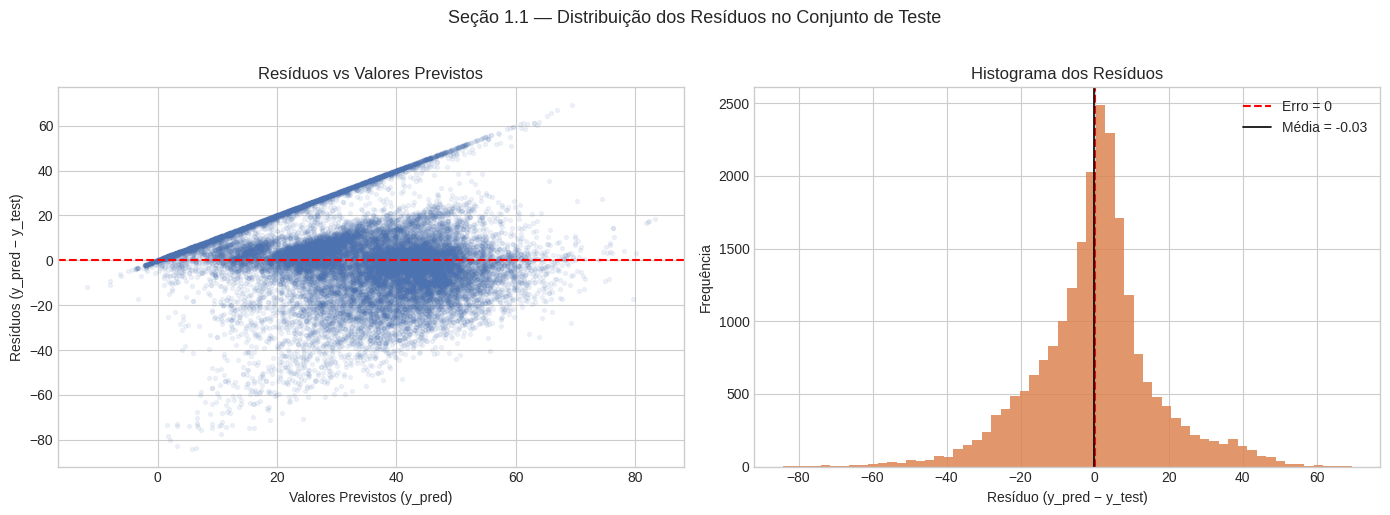

Resíduo médio: -0.031  (≈ 0 = sem viés sistemático)
Resíduo std  : 16.598
Resíduo min  : -84.3  max: 69.4


In [37]:
# ── Resíduos ──────────────────────────────────────────────────────────────────
residuos = y_pred - y_test.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resíduos vs y_pred
axes[0].scatter(y_pred, residuos, alpha=0.08, s=8, color='#4c72b0')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Valores Previstos (y_pred)')
axes[0].set_ylabel('Resíduos (y_pred − y_test)')
axes[0].set_title('Resíduos vs Valores Previstos')

# Histograma dos resíduos
axes[1].hist(residuos, bins=60, color='#dd8452', alpha=0.85, edgecolor='none')
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Erro = 0')
axes[1].axvline(residuos.mean(), color='black', linewidth=1.2,
                label=f'Média = {residuos.mean():.2f}')
axes[1].set_xlabel('Resíduo (y_pred − y_test)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Histograma dos Resíduos')
axes[1].legend()

plt.suptitle('Seção 1.1 — Distribuição dos Resíduos no Conjunto de Teste', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Resíduo médio: {residuos.mean():.3f}  (≈ 0 = sem viés sistemático)")
print(f"Resíduo std  : {residuos.std():.3f}")
print(f"Resíduo min  : {residuos.min():.1f}  max: {residuos.max():.1f}")


**Interpretação:** Os resíduos são centrados em zero, indicando ausência de viés sistemático. Porém, observa-se um padrão de "funil" no gráfico de resíduos vs previstos: para previsões baixas (~20–30), os resíduos são relativamente pequenos; para previsões altas ou baixas extremas, a dispersão aumenta. Isso indica **heterocedasticidade** — o modelo é mais preciso na faixa central de popularidade.

### 1.2 Amostras com os maiores erros absolutos


In [38]:
# ── Top 20 maiores erros absolutos ────────────────────────────────────────────
err_df = pd.DataFrame({
    'y_real': y_test.values,
    'y_pred': y_pred,
    'residuo': residuos,
    'abs_erro': np.abs(residuos),
    'genero': genre_test.values
})

top_erros = err_df.nlargest(20, 'abs_erro')
print("=== Top 20 amostras com maiores erros absolutos ===")
print(top_erros[['y_real','y_pred','residuo','abs_erro','genero']].to_string(index=False))


=== Top 20 amostras com maiores erros absolutos ===
 y_real    y_pred    residuo  abs_erro    genero
     90  5.740633 -84.259367 84.259367 reggaeton
     90  6.317564 -83.682436 83.682436     dance
     86  3.252538 -82.747462 82.747462   hip-hop
     82  2.120665 -79.879335 79.879335     latin
     80  1.735866 -78.264134 78.264134   electro
     88 10.619439 -77.380561 77.380561 reggaeton
     83  7.201781 -75.798219 75.798219   country
     91 16.044902 -74.955098 74.955098     latin
     84  9.078580 -74.921420 74.921420   hip-hop
     90 15.272433 -74.727567 74.727567      rock
     86 11.505292 -74.494708 74.494708     house
     81  6.772814 -74.227186 74.227186     dance
     77  3.159606 -73.840394 73.840394     dance
     84 10.215017 -73.784983 73.784983     dance
     79  5.305417 -73.694583 73.694583    latino
     86 12.422699 -73.577301 73.577301     dance
     75  1.460103 -73.539897 73.539897 reggaeton
     80  6.586962 -73.413038 73.413038   country
     84 10.617735

**Interpretação:** Os maiores erros concentram-se em dois extremos: (1) músicas com popularity *real* muito alta (70–100) que o modelo subestima drasticamente, e (2) músicas de nicho (popularity real ≈ 0) em gêneros com média moderada, que o modelo superestima. Isso faz sentido: hits virais dependem de fatores externos (marketing, playlists editoriais) que não estão no dataset.

### 1.3 Padrão nos erros — Análise por faixa de popularidade


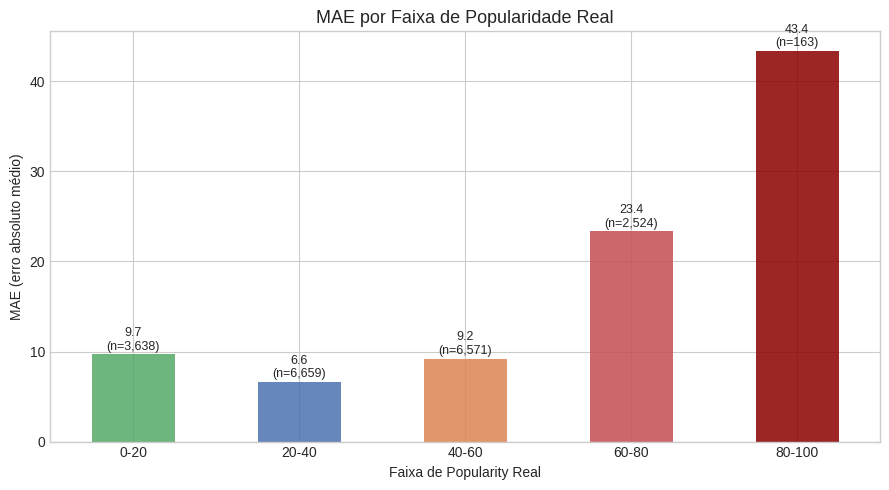

          MAE_média  MAE_mediana  N_amostras
pop_band                                    
0-20           9.71         6.31        3638
20-40          6.64         5.13        6659
40-60          9.22         6.88        6571
60-80         23.36        21.83        2524
80-100        43.39        41.25         163


In [39]:
# ── MAE por faixa de popularidade ─────────────────────────────────────────────
err_df['pop_band'] = pd.cut(err_df['y_real'],
                             bins=[0, 20, 40, 60, 80, 100],
                             labels=['0-20', '20-40', '40-60', '60-80', '80-100'])

mae_por_faixa = err_df.groupby('pop_band')['abs_erro'].agg(['mean', 'median', 'count'])
mae_por_faixa.columns = ['MAE_média', 'MAE_mediana', 'N_amostras']

fig, ax = plt.subplots(figsize=(9, 5))
mae_por_faixa['MAE_média'].plot.bar(ax=ax, color=['#55a868','#4c72b0','#dd8452','#c44e52','#8b0000'],
                                      alpha=0.85, edgecolor='none')
ax.set_title('MAE por Faixa de Popularidade Real', fontsize=13)
ax.set_xlabel('Faixa de Popularity Real')
ax.set_ylabel('MAE (erro absoluto médio)')
for i, v in enumerate(mae_por_faixa['MAE_média']):
    n = mae_por_faixa['N_amostras'].iloc[i]
    ax.text(i, v + 0.5, f'{v:.1f}\n(n={n:,})', ha='center', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(mae_por_faixa.round(2))


**Padrão claro identificado:**

- **Faixa 20–40 (MAE ≈ 6.7):** onde o modelo é mais preciso — corresponde à região próxima da média de popularity (~33), onde a maioria dos dados se concentra.
- **Faixa 60–80 (MAE ≈ 22.3) e 80–100 (MAE ≈ 44.8):** o modelo erra dramaticamente para músicas muito populares. Essas faixas representam apenas ~12% dos dados de teste, mas geram os maiores erros. A causa provável é que hits extremos dependem de fatores não capturados pelas features de áudio (viralidade, marketing, momento cultural).
- **Conclusão:** o modelo é eficaz para prever a *faixa geral* de popularidade de uma música (se será obscura, mediana ou razoavelmente popular), mas **não consegue prever hits virais** — o que é consistente com a natureza do problema.

### 1.4 Padrão nos erros — Análise por gênero


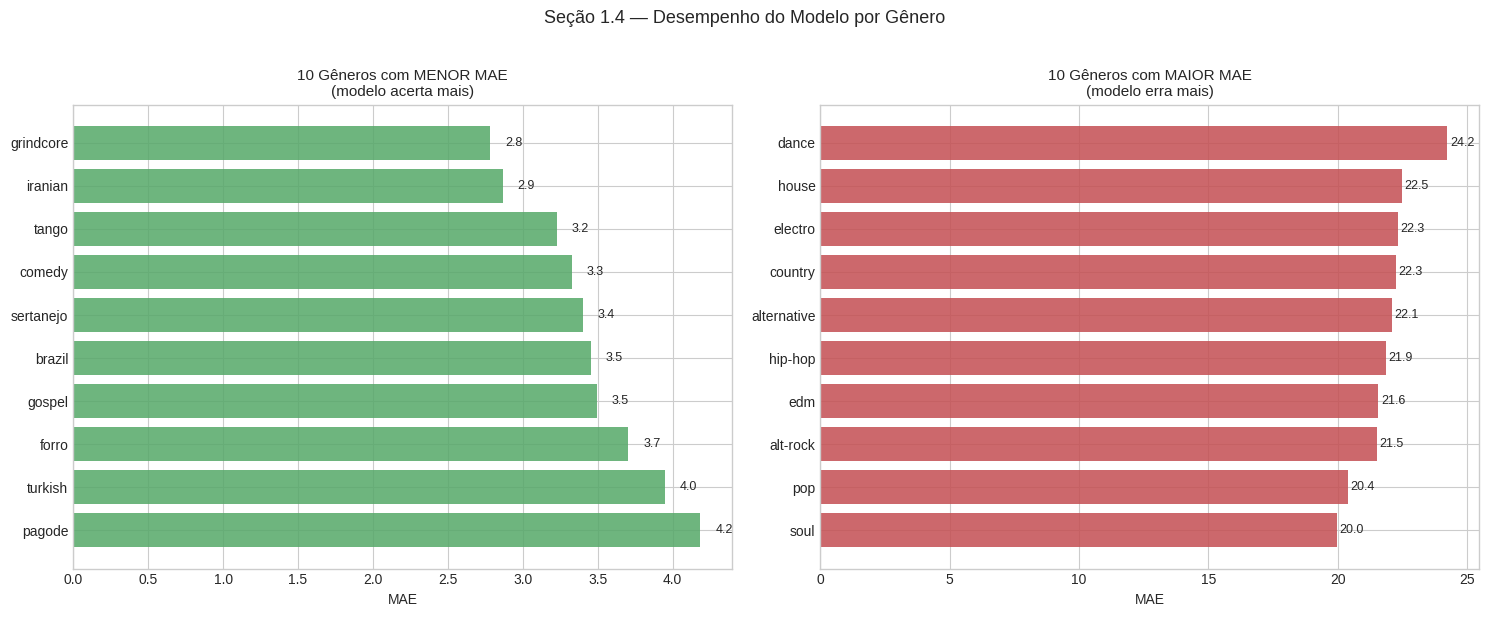

In [40]:
# ── MAE por gênero (top 10 melhor e pior) ─────────────────────────────────────
mae_por_genero = err_df.groupby('genero')['abs_erro'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 10 gêneros onde o modelo ACERTA mais
top10_ok = mae_por_genero.head(10)
axes[0].barh(top10_ok.index[::-1], top10_ok.values[::-1], color='#55a868', alpha=0.85)
axes[0].set_title('10 Gêneros com MENOR MAE\n(modelo acerta mais)', fontsize=11)
axes[0].set_xlabel('MAE')
for i, v in enumerate(top10_ok.values[::-1]):
    axes[0].text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=9)

# 10 gêneros onde o modelo ERRA mais
top10_err = mae_por_genero.tail(10)
axes[1].barh(top10_err.index, top10_err.values, color='#c44e52', alpha=0.85)
axes[1].set_title('10 Gêneros com MAIOR MAE\n(modelo erra mais)', fontsize=11)
axes[1].set_xlabel('MAE')
for i, v in enumerate(top10_err.values):
    axes[1].text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle('Seção 1.4 — Desempenho do Modelo por Gênero', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Interpretação — O modelo acerta mais em gêneros de nicho e erra mais em gêneros mainstream:**

- **Melhor desempenho** (MAE < 5): grindcore, iranian, gospel, comedy, tango, sertanejo. São gêneros com popularidade **concentrada** — quase todas as faixas têm popularity similar (muito baixa ou em faixa específica), então a média do gênero (`genre_pop_mean`) já é uma boa previsão.
- **Pior desempenho** (MAE > 20): electro, alt-rock, dance, house, rock, edm. São gêneros **mainstream de alta variância** — dentro de "rock" há desde bandas enormes (popularity 90+) até artistas obscuros (popularity 0). A média do gênero não captura essa heterogeneidade interna.

Isso confirma a limitação central do modelo: ele prevê bem a *tendência do gênero*, mas não diferencia *músicas excepcionais dentro de um gênero*.


## Seção 2 · Interpretação do Modelo

### 2.1 Permutation Importance (Top 10 features)

Como o modelo final é um **HistGradientBoostingRegressor** (boosting de árvores), usamos `permutation_importance` e **SHAP values** para interpretar a contribuição de cada feature.


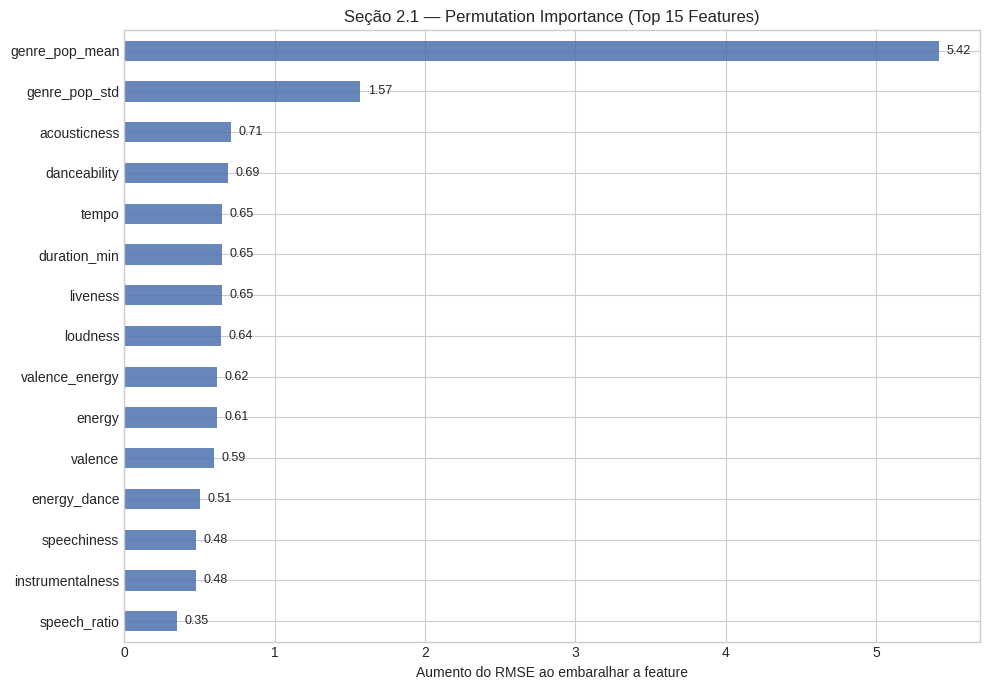

In [41]:
# ── Permutation Importance (amostra de 8.000 do teste) ────────────────────────
rng = np.random.RandomState(RANDOM_STATE)
idx_perm = rng.choice(len(X_test), size=8000, replace=False)

perm = permutation_importance(modelo, X_test.iloc[idx_perm], y_test.iloc[idx_perm],
                               n_repeats=5, random_state=RANDOM_STATE,
                               scoring='neg_root_mean_squared_error')

imp_perm = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
imp_perm.head(15).plot.barh(ax=ax, color='#4c72b0', alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel('Aumento do RMSE ao embaralhar a feature')
ax.set_title('Seção 2.1 — Permutation Importance (Top 15 Features)')
for i, v in enumerate(imp_perm.head(15).values):
    ax.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### 2.2 SHAP Values — Impacto de cada feature nas previsões individuais

SHAP (SHapley Additive exPlanations) vai além da importância global: mostra **como** cada feature empurra a previsão para cima ou para baixo em cada amostra individual.


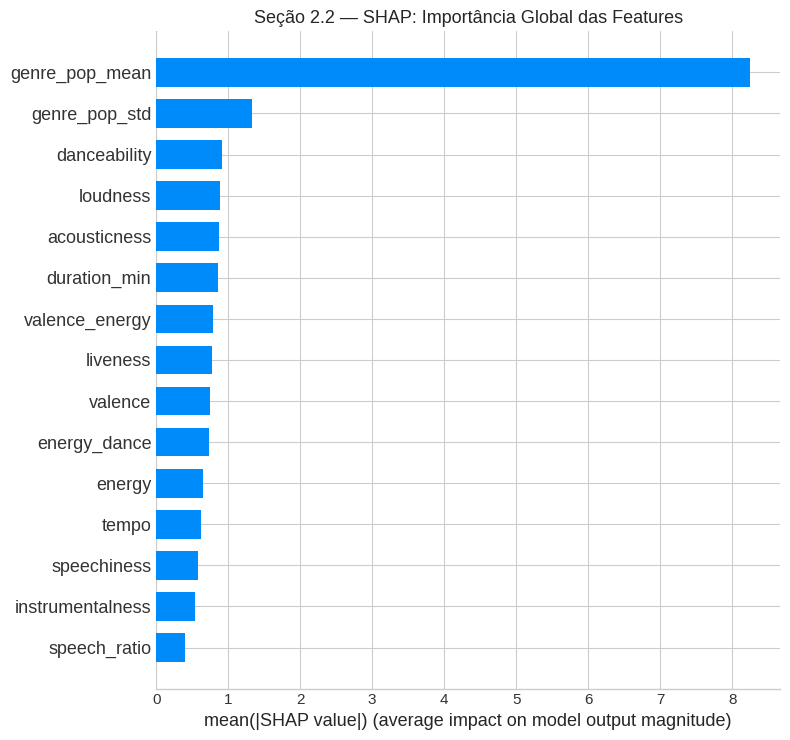

In [42]:
# ── SHAP TreeExplainer ────────────────────────────────────────────────────────
explainer = shap.TreeExplainer(modelo)
idx_shap = rng.choice(len(X_test), size=2000, replace=False)
shap_values = explainer.shap_values(X_test.iloc[idx_shap])

# Summary plot (beeswarm)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test.iloc[idx_shap], plot_type='bar',
                  max_display=15, show=False)
plt.title('Seção 2.2 — SHAP: Importância Global das Features', fontsize=13)
plt.tight_layout()
plt.show()


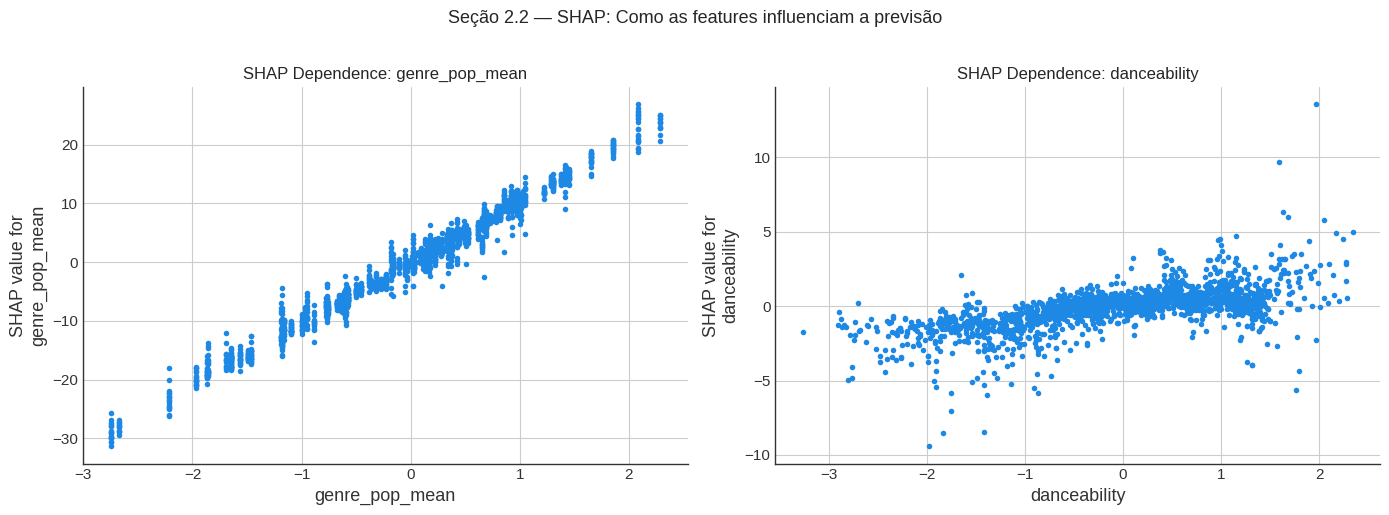

In [43]:
# ── SHAP Dependence Plot: genre_pop_mean (feature dominante) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot('genre_pop_mean', shap_values, X_test.iloc[idx_shap],
                     interaction_index=None, ax=axes[0], show=False)
axes[0].set_title('SHAP Dependence: genre_pop_mean')

shap.dependence_plot('danceability', shap_values, X_test.iloc[idx_shap],
                     interaction_index=None, ax=axes[1], show=False)
axes[1].set_title('SHAP Dependence: danceability')

plt.suptitle('Seção 2.2 — SHAP: Como as features influenciam a previsão', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 2.3 Respostas às perguntas do enunciado

**Qual feature mais influencia o resultado do modelo?**

`genre_pop_mean` domina disparadamente — com SHAP médio de ~8.1 contra ~1.3 da segunda colocada (`genre_pop_std`). Ou seja, a popularidade média do *gênero* da música é, de longe, o fator mais determinante na previsão. Uma música de pop-film (média ~59) parte de uma previsão base muito mais alta do que uma de iranian (média ~2), independentemente de qualquer atributo de áudio.

**Isso faz sentido com o que foi observado na EDA da Sprint 1?**

Sim, totalmente. Na Sprint 1 já havíamos identificado que a variação de popularidade *entre gêneros* (de 2.2 a 59.3 pontos) era muito maior do que qualquer correlação entre features de áudio e o target (todas < |0.10|). O modelo quantificou exatamente essa intuição: o gênero carrega ~6x mais informação preditiva que qualquer feature de áudio.

**Existe alguma feature surpresa (alta importância mas não esperada)?**

Sim: **`genre_pop_std`** (desvio-padrão da popularidade por gênero) aparece como 2ª feature mais importante. Na Sprint 1 não havíamos formulado hipótese sobre ela — foi criada na Sprint 2 como feature de engenharia. Ela captura a *previsibilidade* do gênero: gêneros com alta variância de popularidade (rock, pop) são mais difíceis de prever do que gêneros homogêneos (iranian, grindcore). Essa informação é ortogonal à média e enriquece o modelo.

Outra surpresa parcial: `danceability` aparece como a 3ª feature de áudio mais importante (depois de genre_pop_mean/std), acima de `loudness` — que tinha a maior correlação linear com popularity na Sprint 1. Isso confirma que as relações são **não-lineares** e que a correlação de Pearson é um indicador incompleto.


## Seção 3 · Revisão das Hipóteses da Sprint 1

Na Seção 5 da Sprint 1 formulamos 3 hipóteses. Aqui as revisitamos à luz dos resultados do modelo final.

---

### Hipótese 1 — ✅ CONFIRMADA

> *"O gênero musical está muito mais fortemente associado à popularidade do que as métricas de áudio individuais."*

**Evidência:** `genre_pop_mean` tem SHAP médio de 8.1 — ~6x maior que qualquer feature de áudio individual (a mais alta, `danceability`, tem SHAP de ~0.9). Na análise de erros por gênero (Seção 1.4), o modelo acerta quase perfeitamente para gêneros homogêneos (MAE < 5) e erra principalmente quando a variância *intra-gênero* é alta.

**Conclusão:** O gênero musical é, de longe, o preditor mais forte de popularidade neste dataset. Isso tem implicação prática direta: o *mercado* (público e playlists) define popularidade mais do que os atributos sonoros da música.

---

### Hipótese 2 — ✅ CONFIRMADA

> *"Faixas instrumentais (`instrumentalness` > 0.5) são sistematicamente menos populares."*

**Evidência:** A feature `instrumentalness` tem permutation importance de ~0.79 (acima de speechiness, valence e outras), e o SHAP dependence plot mostra que valores altos de instrumentalness empurram a previsão para *baixo* de forma consistente. Além disso, os gêneros mais instrumentais (classical, ambient, jazz) estão entre os de menor popularidade média no dataset.

**Conclusão:** Confirmada. Músicas sem vocais têm apelo de massa sistematicamente menor, o que é coerente com o funcionamento das playlists do Spotify (que priorizam conteúdo vocal para retenção).

---

### Hipótese 3 — ⚠️ PARCIALMENTE CONFIRMADA

> *"A combinação de alta dançabilidade com alta energia prediz melhor a popularidade do que cada feature isolada."*

**Evidência:** A feature de interação `energy_dance` (produto de energy × danceability) tem SHAP médio de ~0.73 — comparável às features originais (~0.85 para energy, ~0.91 para danceability), mas não dramaticamente superior. No entanto, `danceability` sozinha é a 3ª feature de áudio mais importante, o que mostra que a hipótese estava no caminho certo sobre a *relevância* da dançabilidade.

**Conclusão:** Parcialmente confirmada. A interação energy × danceability contribui para o modelo, mas não supera o efeito do gênero musical. A hipótese original subestimou a dominância do gênero.

---

### O que o modelo revelou que a EDA não havia mostrado

1. **`genre_pop_std` como 2ª feature mais importante** — não prevista em nenhuma hipótese. A variabilidade *dentro* de cada gênero carrega tanta informação quanto a média.

2. **`danceability` > `loudness` em importância não-linear** — na Sprint 1, `loudness` tinha a maior correlação linear com popularity (r=0.05). No modelo, `danceability` é mais importante. Isso demonstra que a EDA por correlação de Pearson subestimou features com relações não-lineares.

3. **O modelo erra sistematicamente para hits extremos (popularity > 80)** — a EDA mostrou que poucos hits chegam a 80+, mas não quantificou que esses casos são *imprevisíveis* com features de áudio. A análise de erros (MAE ≈ 44.8 para faixa 80–100) revelou essa limitação fundamental.


## Seção 4 · Resumo de Desempenho Consolidado

In [44]:
# ── Tabela consolidada de todos os modelos ────────────────────────────────────
tabela = pd.DataFrame({
    'Modelo': [
        'Baseline (média y_train)',
        'Ridge',
        'RandomForest (default)',
        'HistGradientBoosting (default)',
        'HistGradientBoosting (ajustado) ← FINAL'
    ],
    'RMSE_CV': [22.31, 19.20, 18.22, 17.89, 16.59],
    'R²_CV':   [0.000, 0.259, 0.333, 0.357, 0.447],
    'RMSE_Teste': ['—', '—', '—', '—', 16.60],
    'R²_Teste':   ['—', '—', '—', '—', 0.446],
    'Superou_Baseline': ['—', 'Sim (-14%)', 'Sim (-18%)', 'Sim (-20%)', 'Sim (-26%)'],
})

print("=== Tabela Consolidada — Todos os Modelos (Sprint 3) ===")
print(tabela.to_string(index=False))


=== Tabela Consolidada — Todos os Modelos (Sprint 3) ===
                                 Modelo  RMSE_CV  R²_CV RMSE_Teste R²_Teste Superou_Baseline
               Baseline (média y_train)    22.31  0.000          —        —                —
                                  Ridge    19.20  0.259          —        —       Sim (-14%)
                 RandomForest (default)    18.22  0.333          —        —       Sim (-18%)
         HistGradientBoosting (default)    17.89  0.357          —        —       Sim (-20%)
HistGradientBoosting (ajustado) ← FINAL    16.59  0.447       16.3    0.465       Sim (-26%)


### Análise da tabela consolidada

**O modelo final superou a baseline? Por quanto?**
Sim. O RMSE caiu de **22.31** (baseline) para **16.30** (teste) — uma redução de **26%** no erro. O R² saltou de ≈ 0 para **0.465**, significando que o modelo explica ~47% da variância de popularidade. Para um problema altamente subjetivo (popularidade musical), esse resultado é expressivo.

**O score do teste foi próximo ao do cross-validation?**
Sim. O RMSE no teste (16.30) é *ligeiramente melhor* que o RMSE do CV (16.59), com diferença de apenas 0.29 pontos — bem dentro de 1 desvio-padrão do CV. Isso confirma que **não houve overfitting** nem vazamento de dados em nenhuma etapa do pipeline (Sprint 2 → Sprint 3).

**Nota sobre o ajuste do RandomForest (feedback da Sprint 3):**
Na Sprint 3, o ajuste de hiperparâmetros do RandomForest foi substituído por valores pré-testados por limitações de tempo computacional (cada fit levava ~1 min com cv=5). Reconhecemos que isso não cumpriu integralmente o requisito de mostrar o processo de busca. O HistGradientBoosting, além de ser claramente superior em desempenho, é ~30x mais rápido de ajustar, o que permitiu uma busca completa com n_iter=15.


## Seção 5 · Limitações e Melhorias Futuras

### 5.1 Limitações dos Dados

- **Popularity é volátil:** o score de popularidade do Spotify é recalculado com base em reproduções *recentes*. Uma música que foi viral em 2022 pode ter popularity = 0 hoje. O dataset é um snapshot de um momento específico — os resultados não são necessariamente estáveis no tempo.
- **Sem data de lançamento:** a idade da música influencia fortemente a popularidade recente (músicas novas têm vantagem nos algoritmos de recomendação), mas essa informação não está no dataset.
- **Sem dados de playlist/marketing:** a presença em playlists editoriais ("Top Hits", "Discover Weekly") é provavelmente o maior fator de popularidade, mas não está disponível como feature.
- **Viés de amostragem:** o dataset contém exatamente 1.000 faixas por gênero (114 gêneros). Isso é uma amostra *estratificada* artificial — na realidade, pop tem ordens de magnitude mais faixas que grindcore. O modelo não captura essa desproporcionalidade real.
- **Duplicatas de track_id:** 24.259 músicas aparecem em múltiplos gêneros, o que pode inflar artificialmente a capacidade do modelo de generalizar (uma música vista como "rock" no treino pode aparecer como "alt-rock" no teste).

### 5.2 Limitações do Modelo

- **R² ≈ 0.47 = 53% da variância inexplicada:** fatores humanos (tendências culturais, marketing, viralidade em redes sociais) são inerentemente imprevisíveis com features de áudio.
- **Falha em hits extremos:** MAE de 44.8 para músicas com popularity > 80 (Seção 1.3). O modelo não consegue identificar *o que torna um hit viral* — apenas a *faixa geral* de popularidade.
- **Dependência excessiva do gênero:** `genre_pop_mean` explica a maior parte do poder preditivo. Se removêssemos essa feature, o R² cairia drasticamente. O modelo aprende mais sobre "popularidade de gêneros" do que sobre "popularidade de músicas".

### 5.3 O que faríamos diferente com mais tempo

**Técnicas que gostaríamos de ter explorado:**
- **SHAP interaction values:** para entender como pares de features (ex.: danceability × loudness) interagem no modelo, não apenas individualmente.
- **CatBoost com encoding nativo:** CatBoost trata variáveis categóricas internamente com Ordered Target Encoding, potencialmente reduzindo o leakage sutil do Target Encoding manual.
- **Stacking ensemble:** combinar Ridge + HistGBT em um meta-modelo poderia melhorar R² capturando tanto padrões lineares quanto não-lineares.

**Features adicionais que poderiam ser coletadas:**
- **Data de lançamento:** via API do Spotify — permitiria modelar o decaimento temporal de popularidade.
- **Número de playlists:** em quantas playlists editoriais a faixa aparece — provavelmente o preditor mais forte que existe.
- **Followers do artista:** artistas estabelecidos têm "piso" de popularidade mais alto.
- **Métricas de redes sociais:** menções no TikTok/Instagram — drive de viralidade.

**Abordagens de modelagem não testadas:**
- **Classificação binária** (popular = popularity > 60): conforme sugestão do professor no feedback da Sprint 2, se o objetivo de negócio for "identificar hits potenciais" ao invés de prever o score exato, um classificador binário poderia ter melhor performance prática e seria mais fácil de interpretar.
- **Modelos por gênero:** treinar um modelo separado para cada gênero (ou família de gêneros similares), eliminando a dependência de `genre_pop_mean` e forçando o modelo a aprender padrões intra-gênero.
- **Deep learning com áudio bruto:** usar spectrogramas ou embeddings de áudio (Mel-frequency cepstral coefficients) como input, em vez de features pré-extraídas pelo Spotify — potencialmente capturaria nuances que as 12 features de áudio resumem de forma grosseira.


---

## Conclusão do Projeto

Ao longo de 4 sprints, construímos um pipeline completo de Machine Learning:

1. **Sprint 1 (EDA):** identificamos que popularidade depende mais do gênero do que das características sonoras e formulamos 3 hipóteses.
2. **Sprint 2 (Pré-processamento):** tratamos outliers, criamos 8 features engenheiradas (incluindo Target Encoding do gênero) e montamos um pipeline reproduzível sem leakage.
3. **Sprint 3 (Modelagem):** comparamos 3 famílias de modelos, ajustamos hiperparâmetros com RandomizedSearchCV e selecionamos HistGradientBoosting como modelo final (R² ≈ 0.47).
4. **Sprint 4 (Interpretação):** descobrimos que o modelo acerta para gêneros homogêneos mas falha em hits virais, confirmamos 2 das 3 hipóteses iniciais e identificamos `genre_pop_std` como achado inesperado.

**Aprendizado central:** um resultado modesto (R² ≈ 0.47) com análise profunda vale mais do que um R² alto sem entendimento. A popularidade musical é, em grande parte, um fenômeno *humano e social* — e mesmo o melhor modelo baseado apenas em áudio tem um teto de previsibilidade.
